In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Define data path
DATA_PATH = "../data/raw/"

# Load all tables
student_info = pd.read_csv(DATA_PATH + "studentInfo.csv")
student_vle = pd.read_csv(DATA_PATH + "studentVle.csv")
student_assessment = pd.read_csv(DATA_PATH + "studentAssessment.csv")
assessments = pd.read_csv(DATA_PATH + "assessments.csv")
student_registration = pd.read_csv(DATA_PATH + "studentRegistration.csv")
vle = pd.read_csv(DATA_PATH + "vle.csv")
courses = pd.read_csv(DATA_PATH + "courses.csv")

print("All tables loaded successfully!")
print(f"studentInfo:         {student_info.shape}")
print(f"studentVle:          {student_vle.shape}")
print(f"studentAssessment:   {student_assessment.shape}")
print(f"assessments:         {assessments.shape}")
print(f"studentRegistration: {student_registration.shape}")
print(f"vle:                 {vle.shape}")
print(f"courses:             {courses.shape}")

All tables loaded successfully!
studentInfo:         (32593, 12)
studentVle:          (10655280, 6)
studentAssessment:   (173912, 5)
assessments:         (206, 6)
studentRegistration: (32593, 5)
vle:                 (6364, 6)
courses:             (22, 3)


In [3]:
# Check studentInfo
print("=== studentInfo ===")
print(student_info.head())
print(f"\nColumns: {list(student_info.columns)}")
print(f"\nFinal result distribution:")
print(student_info['final_result'].value_counts())
print(f"\nAt-risk rate (Withdrawn):")
withdrawn = (student_info['final_result'] == 'Withdrawn').sum()
total = len(student_info)
print(f"{withdrawn} / {total} = {withdrawn/total*100:.1f}%")

=== studentInfo ===
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60      

In [4]:
# Create at-risk labels
# Withdrawn = 1 (at risk)
# Pass/Distinction = 0 (not at risk)

student_info['at_risk'] = (
    student_info['final_result'] == 'Withdrawn'
).astype(int)

print("Label distribution:")
print(student_info['at_risk'].value_counts())
print(f"\nAt-risk students:     {student_info['at_risk'].sum()}")
print(f"Not at-risk students: {(student_info['at_risk']==0).sum()}")
print(f"Total students:       {len(student_info)}")

Label distribution:
at_risk
0    22437
1    10156
Name: count, dtype: int64

At-risk students:     10156
Not at-risk students: 22437
Total students:       32593


In [5]:
# Explore VLE interactions
print("=== studentVle ===")
print(student_vle.head())
print(f"\nColumns: {list(student_vle.columns)}")
print(f"\nDate range:")
print(f"Min date: {student_vle['date'].min()}")
print(f"Max date: {student_vle['date'].max()}")
print(f"\nTotal interactions: {len(student_vle):,}")

# Merge with vle to get activity types
student_vle_merged = student_vle.merge(
    vle[['id_site', 'activity_type']], 
    on='id_site', 
    how='left'
)

print(f"\nActivity type distribution:")
print(student_vle_merged['activity_type'].value_counts().head(10))

=== studentVle ===
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1

Columns: ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']

Date range:
Min date: -25
Max date: 269

Total interactions: 10,655,280

Activity type distribution:
activity_type
forumng          2408457
oucontent        1963782
subpage          1949898
homepage         1735226
quiz              914573
resource          813185
url               407716
ouwiki            178165
oucollaborate      65793
externalquiz       50910
Name: count, dtype: int64


In [6]:
# Explore assessments
print("=== assessments ===")
print(assessments.head(10))
print(f"\nAssessment types:")
print(assessments['assessment_type'].value_counts())

print(f"\n=== studentAssessment ===")
print(student_assessment.head())
print(f"\nColumns: {list(student_assessment.columns)}")
print(f"\nMissing scores:")
print(student_assessment.isnull().sum())

# Merge to get submission latency
assessment_merged = student_assessment.merge(
    assessments[['id_assessment', 'assessment_type', 'date']],
    on='id_assessment',
    how='left'
)
assessment_merged['submission_latency'] = (
    assessment_merged['date_submitted'] - 
    assessment_merged['date']
)
print(f"\nSubmission latency stats (days):")
print(assessment_merged['submission_latency'].describe())

=== assessments ===
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0
5         AAA             2013J           1757            Exam    NaN   100.0
6         AAA             2014J           1758             TMA   19.0    10.0
7         AAA             2014J           1759             TMA   54.0    20.0
8         AAA             2014J           1760             TMA  117.0    20.0
9         AAA             2014J           1761             TMA  166.0    20.0

Assessment types:
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

=== studentAssessment ==

=== Withdrawal Timing Analysis ===
Total withdrawals: 10072

Withdrawal timing stats (days):
count    10072.000000
mean        49.757645
std         82.460890
min       -365.000000
25%         -2.000000
50%         27.000000
75%        109.000000
max        444.000000
Name: date_unregistration, dtype: float64

Withdraw before week 4: 5055
Percentage: 50.2%


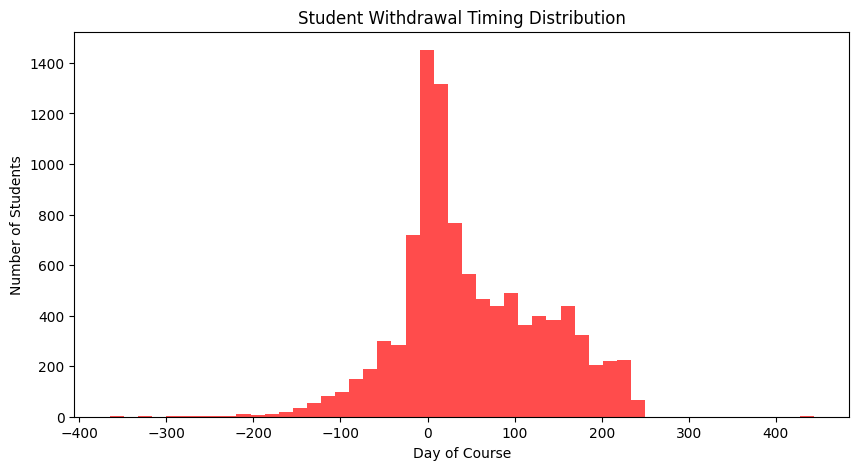

Chart saved!


In [7]:
# Analyze withdrawal timing
print("=== Withdrawal Timing Analysis ===")

# Get withdrawal dates
withdrawals = student_registration[
    student_registration['date_unregistration'].notna()
].copy()

print(f"Total withdrawals: {len(withdrawals)}")
print(f"\nWithdrawal timing stats (days):")
print(withdrawals['date_unregistration'].describe())

# How many withdraw before week 4 (day 28)?
early_withdrawal = (withdrawals['date_unregistration'] <= 28).sum()
print(f"\nWithdraw before week 4: {early_withdrawal}")
print(f"Percentage: {early_withdrawal/len(withdrawals)*100:.1f}%")

# Plot withdrawal timing
plt.figure(figsize=(10, 5))
plt.hist(withdrawals['date_unregistration'].dropna(), 
         bins=50, color='red', alpha=0.7)
plt.title('Student Withdrawal Timing Distribution')
plt.xlabel('Day of Course')
plt.ylabel('Number of Students')
plt.savefig('../results/figures/withdrawal_timing.png')
plt.show()
print("Chart saved!")

In [8]:
# Document all findings
print("=" * 50)
print("DATA EXPLORATION SUMMARY")
print("=" * 50)
print(f"\nDataset: OULAD (Open University Learning Analytics)")
print(f"Total students:           {len(student_info):,}")
print(f"Total VLE interactions:   {len(student_vle):,}")
print(f"Total assessments:        {len(student_assessment):,}")
print(f"Total courses:            {len(courses):,}")
print(f"\nAt-risk students:         {student_info['at_risk'].sum():,}")
print(f"Not at-risk students:     {(student_info['at_risk']==0).sum():,}")
print(f"At-risk rate:             {student_info['at_risk'].mean()*100:.1f}%")
print(f"\nActivity types available:")
activity_types = student_vle_merged['activity_type'].unique()
for a in sorted(activity_types):
    print(f"  - {a}")
print(f"\nAssessment types: TMA, CMA, Exam")
print(f"Date range: Day {student_vle['date'].min()} to Day {student_vle['date'].max()}")
print(f"\nWithdrawal timing:")
print(f"  50% withdraw before week 4")
print(f"  Mean withdrawal day: 49.8")
print(f"\nData exploration complete!")
print(f"Next step: Feature Engineering")

DATA EXPLORATION SUMMARY

Dataset: OULAD (Open University Learning Analytics)
Total students:           32,593
Total VLE interactions:   10,655,280
Total assessments:        173,912
Total courses:            22

At-risk students:         10,156
Not at-risk students:     22,437
At-risk rate:             31.2%

Activity types available:
  - dataplus
  - dualpane
  - externalquiz
  - folder
  - forumng
  - glossary
  - homepage
  - htmlactivity
  - oucollaborate
  - oucontent
  - ouelluminate
  - ouwiki
  - page
  - questionnaire
  - quiz
  - repeatactivity
  - resource
  - sharedsubpage
  - subpage
  - url

Assessment types: TMA, CMA, Exam
Date range: Day -25 to Day 269

Withdrawal timing:
  50% withdraw before week 4
  Mean withdrawal day: 49.8

Data exploration complete!
Next step: Feature Engineering
